In [45]:
import numpy as np
import os, glob
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False

import h5py

from scipy.signal import savgol_filter

from scipy.optimize import curve_fit
from scipy.fft import rfft, irfft, rfftfreq

import sys
sys.path.append('../')
import analysis_utils as utils

utils.load_plotting_setting()

In [46]:
import importlib
importlib.reload(utils)

<module 'analysis_utils' from '/Users/yuhan/work/nanospheres/dm_nanospheres/analysis_notebooks/../analysis_utils.py'>

In [47]:
m = 2000 * (83e-9)**3 * 4 * np.pi / 3
kb = 1.38e-23
hbar = 1.054571817e-34
omega0 = 2 * np.pi * 50292.96875

## Read in the calculated variance

In [48]:
c_mv = 6.711030676159362e-08

# f = h5py.File(r'/Users/yuhan/work/nanospheres/data/reheating_data/sphere_20250406/reheating_averaged_varaince.h5py')
f = h5py.File(r'/Users/yuhan/work/nanospheres/data/reheating_data/sphere_20250406/reheating_averaged_varaince_20_100khz.h5py')

var_0 = f['averaged_variance']['1_7e-8mbar'][:]
var_1 = f['averaged_variance']['4_8e-8mbar'][:]
var_2 = f['averaged_variance']['9_2e-8mbar'][:]
var_3 = f['averaged_variance']['2_2e-7mbar'][:]
var_4 = f['averaged_variance']['1_3e-6mbar'][:]
f.close()

#### Perform linear fit to derive heating rate

In [49]:
var_unfiltered = [var_0, var_1, var_2, var_3, var_4]

def func(x, a, b):
    return a*x + b

lb, ub = 30000, 150000

tt = 2e-6 * np.arange(var_0.size)
tt_fit = tt[lb:ub] - tt[lb]

slope_fit = []
b_fit = []
for var in var_unfiltered:
    var_mean_fit = var[lb:ub] * c_mv**2
    popt, pcov = curve_fit(func, tt_fit, var_mean_fit)
    slope_fit.append(popt[0])
    b_fit.append(popt[1])

# gamma_heating = 0.5 * m * omega0**2 * np.array(slope_fit) / (hbar * omega0)
gamma_heating = m * omega0**2 * np.array(slope_fit) / (hbar * omega0)
gamma_heating_khz = gamma_heating / (2 * np.pi * 1000)

print(gamma_heating_khz)

[ 38.25551729  40.83880798  48.39168537  65.84119724 201.9365123 ]


In [50]:
pressures = [1.7e-8, 4.8e-8, 9.2e-8, 2.2e-7, 1.3e-6]

popt, pcov = curve_fit(func, pressures, gamma_heating_khz, sigma=gamma_heating_khz*0.15)
gamma_ba, gamma_th = popt[1], popt[0]

print(fr'Measured heating rate @1.7e-8 mbar: {gamma_heating_khz[0]:.3f} \pm {gamma_heating_khz[0]*0.15:.3f} kHz')
print(fr'Estimated gas collision heating rate@1.7e-8 mbar: {gamma_th * 1.7e-8:.3f} \pm {gamma_th * 1.7e-8 * 0.15:.3f} kHz')
print(fr'Estimated gas collision heating rate@7.9e-9 mbar: {gamma_th * 7.9e-9:.3f} \pm {gamma_th * 7.9e-9 * 0.15:.3f} kHz')
print(fr'Fitted photon recoil heating rate: {gamma_ba:.3f} \pm {gamma_ba * 0.15:.3f} kHz')


Measured heating rate @1.7e-8 mbar: 38.256 \pm 5.738 kHz
Estimated gas collision heating rate@1.7e-8 mbar: 2.201 \pm 0.330 kHz
Estimated gas collision heating rate@7.9e-9 mbar: 1.023 \pm 0.153 kHz
Fitted photon recoil heating rate: 35.833 \pm 5.375 kHz


#### Estimate the predicted thermal decoherence rate

In [130]:
def get_thermal_heating_rate_khz(p_mbar, m_sphere, r_sphere, omega0, gas='hydrogen', T_int=1000):
    kb = 1.380649e-23

    p_pascal = p_mbar * 100

    R = 8.3144  # J/(mol K)
    if gas == 'water':
        m_gas = 18.01528e-3
    elif gas == 'hydrogen':
        m_gas = 2.016e-3   # kg / mol
        
    T_imp = 295     # K
    T_em = 0.65 * (T_int - T_imp) + T_imp
    print(T_em)

    accom_factor = 0.9
    vbar = np.sqrt(8 * R * T_imp / (np.pi * m_gas))  # m/s

    small_gamma_th_imp = (32/3) * r_sphere**2 * p_pascal / (m_sphere * vbar)
    small_gamma_th_em = small_gamma_th_imp * (np.sqrt(T_em / T_imp) * np.pi / 8) * accom_factor
    big_gamma_th_imp = small_gamma_th_imp * kb * T_imp / (hbar * omega0)
    big_gamma_th_em = small_gamma_th_em * kb * T_em / (hbar * omega0)
    big_gamma_th = big_gamma_th_imp + big_gamma_th_em

    return big_gamma_th / (2 * np.pi * 1000)

753.25
753.25


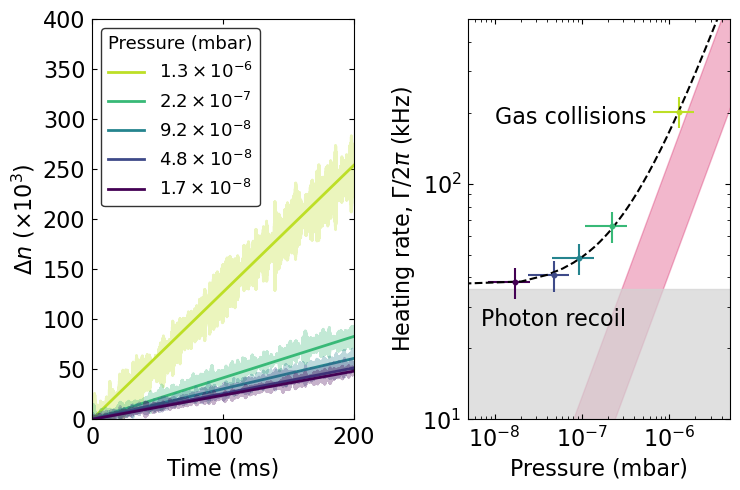

In [134]:
cmap = plt.colormaps.get_cmap('viridis')
colors = cmap(np.linspace(0, 0.9, 5))

fig, axes = plt.subplots(1, 2, figsize=(7.5, 5))

labels=[r'$1.7 \times 10^{-8}$', r'$4.8 \times 10^{-8}$', r'$9.2 \times 10^{-8}$', r'$2.2 \times 10^{-7}$', r'$1.3 \times 10^{-6}$']

xx = np.linspace(1e-10, 1e-5, 500)
heating_rate_khz_h2 = get_thermal_heating_rate_khz(xx, m, 83e-9, omega0, 'hydrogen', 1000)
heating_rate_khz_water = get_thermal_heating_rate_khz(xx, m, 83e-9, omega0, 'water', 1000)

axes[1].fill_between(xx, heating_rate_khz_h2, heating_rate_khz_water, color='#D41159', alpha=0.3)

tt = np.arange(500000) * 2e-6
tt_fit = np.arange(280000) * 2e-6
for i, zvar in enumerate(np.flip(np.asarray(z_var_filtered), axis=0)):
    axes[0].plot(tt/1e-3 - 47, m * omega0**2 * (var_unfiltered[4-i] * c_mv**2 - np.min(zvar)) / (hbar * omega0) / 1000,
                 alpha=0.3, color=colors[4-i], linewidth=2, rasterized=True)
    axes[0].plot(tt_fit/1e-3 - 47, m * omega0**2 * (slope_fit[4-i] * (tt_fit-47e-3)) / (hbar * omega0) / 1000,
                 color=colors[4-i], label=labels[4-i], linewidth=2, antialiased=True)

    # axes[0].plot(tt/1e-3 - 47, (zvar - np.min(zvar))/1e-18, color=colors[4-i], label=labels[4-i])

    # Assume 15% error on the measured heating rate, dominated by uncertainty in electric field
    # and detection drift
    axes[1].errorbar(pressures[i], gamma_heating_khz[i], xerr=pressures[i]/2, yerr=gamma_heating_khz[i]*0.15, color=colors[i], fmt='.', markersize=6.5)

axes[1].plot(xx, gamma_ba + gamma_th * xx, 'k--', label='Fit')
# axes[1].plot(xx, gamma_ba + heating_rate_khz_water, 'k-', label='Theory')
# axes[1].plot(xx, np.full_like(xx, gamma_ba), 'k-')
# axes[1].plot(xx, gamma_th * xx, 'k-')
axes[1].fill_between(xx, 0, gamma_ba, color='lightgrey', alpha=0.7)

axes[0].set_xlim(0, 200)
axes[0].set_ylim(0, 400)
# axes[0].set_ylim(0, 25)
axes[0].legend(frameon=True, loc='upper left', edgecolor='k', title='Pressure (mbar)', fontsize=13, title_fontsize=13)

axes[1].set_xlim(5e-9, 5e-6)
axes[1].set_ylim(10, 500)
# axes[1].legend(frameon=False, fontsize=12)

axes[0].set_xlabel('Time (ms)', fontsize=16)
# axes[0].set_ylabel(r'$\langle z^2 \rangle$ (nm$^2$)', fontsize=16)
axes[0].set_ylabel(r'$\Delta n$ ($\times 10^3$)', fontsize=16)

axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Pressure (mbar)', fontsize=16)
axes[1].set_ylabel(r'Heating rate, $\Gamma / 2 \pi$ (kHz)', fontsize=16)

axes[1].text(1e-8, 180, 'Gas collisions', color='k', fontsize=16)
axes[1].text(7e-9, 25, 'Photon recoil', fontsize=16)

for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=16, pad=5)

fig.align_labels()
fig.tight_layout()

# plt.savefig('../paper_plots/reheating_measurement.pdf', dpi=600)

753.25
295.0
1.8043371750355277


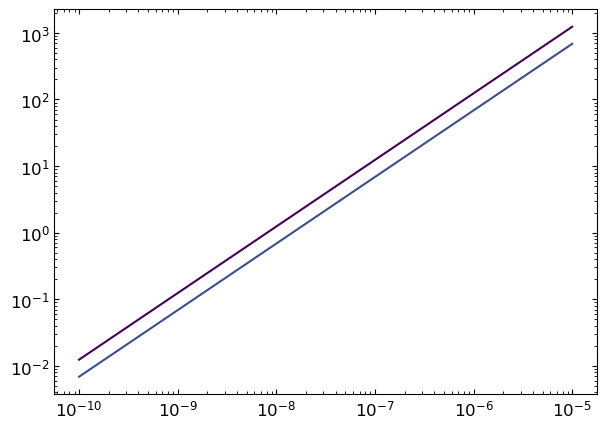

In [132]:
xx = np.linspace(1e-10, 1e-5, 500)

heating_rate_khz_water = get_thermal_heating_rate_khz(xx, m, 83e-9, omega0, 'water', 1000)
heating_rate_khz_water_cold = get_thermal_heating_rate_khz(xx, m, 83e-9, omega0, 'water', 295)

print(np.mean(heating_rate_khz_water / heating_rate_khz_water_cold))
plt.plot(xx, heating_rate_khz_water)
plt.plot(xx, heating_rate_khz_water_cold)

plt.xscale('log')
plt.yscale('log')

#### Perform exponential fit to derive damping rate

In [39]:
def func_expo(x, A, gamma):
    return A * np.exp(-1 * gamma * x)

lb, ub = 300000, 500000

tt_fit = tt[lb:ub] - tt[lb]
a_fit, gamma_fb_fit = [], []
for var in var_unfiltered:
    var_mean_fit = var[lb:ub] * c_mv**2
    popt, pcov = curve_fit(func_expo, tt_fit, var_mean_fit)

    a_fit.append(popt[0])
    gamma_fb_fit.append(popt[1])

gamma_fb_hz = np.asarray(gamma_fb_fit)
print(fr'Fitted damping rate $\gamma / 2 \pi$: {gamma_fb_hz[0]/(2*np.pi):.2f} \pm {gamma_fb_hz[0]/(2*np.pi)*0.15:.2f} Hz')

Fitted damping rate $\gamma / 2 \pi$: 0.46 \pm 0.07 Hz
